In [1]:
# Import relevant packages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
# Download the data
!wget -O penn_jae.dat https://www.dropbox.com/scl/fi/zyrqkllj4ac6gullxlnp0/penn_jae.dat?rlkey=32f2j43v1ax68ruhy82he9vtm&dl=0

# Import data
data = pd.read_csv('penn_jae.dat', sep=r"\s+")
print(data.head())
print(data.shape)

--2026-01-11 03:34:15--  https://www.dropbox.com/scl/fi/zyrqkllj4ac6gullxlnp0/penn_jae.dat?rlkey=32f2j43v1ax68ruhy82he9vtm
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc7f4017c86206664d63056434a9.dl.dropboxusercontent.com/cd/0/inline/C4v4ultcZYTfNj235jsQUyQ8MM-y_e5x2OH0V3P8RX3EDlI6eyRhFl4uYkt9JwX8wjfTy9enwAQh3GctlX3Xdb5kPXWTBRtqQpJoeDMFYLmsFSVeMhvgAbV6F1BPQzrHtqHUD5girIQA08jRyEZWI3JL/file# [following]
--2026-01-11 03:34:16--  https://uc7f4017c86206664d63056434a9.dl.dropboxusercontent.com/cd/0/inline/C4v4ultcZYTfNj235jsQUyQ8MM-y_e5x2OH0V3P8RX3EDlI6eyRhFl4uYkt9JwX8wjfTy9enwAQh3GctlX3Xdb5kPXWTBRtqQpJoeDMFYLmsFSVeMhvgAbV6F1BPQzrHtqHUD5girIQA08jRyEZWI3JL/file
Resolving uc7f4017c86206664d63056434a9.dl.dropboxusercontent.com (uc7f4017c86206664d63056434a9.dl.dropboxusercontent.com)... 162.125.5.15, 2620:1

In [3]:
# Drop variables we won't use (inuidur2 and abdt)
data = data.drop(columns=['inuidur2', 'abdt'])

# Quick sanity check - get summaries of remaining variables
print(data.describe())


                 tg      inuidur1        female         black      hispanic  \
count  13913.000000  13913.000000  13913.000000  13913.000000  13913.000000   
mean       2.568892     12.914828      0.402142      0.116653      0.036369   
std        2.009935     10.573689      0.490348      0.321018      0.187213   
min        0.000000      1.000000      0.000000      0.000000      0.000000   
25%        1.000000      3.000000      0.000000      0.000000      0.000000   
50%        2.000000     10.000000      0.000000      0.000000      0.000000   
75%        4.000000     25.000000      1.000000      0.000000      0.000000   
max        6.000000     52.000000      1.000000      1.000000      1.000000   

            othrace           dep            q1            q2            q3  \
count  13913.000000  13913.000000  13913.000000  13913.000000  13913.000000   
mean       0.005750      0.444045      0.013656      0.206498      0.237691   
std        0.075613      0.757590      0.116064    

In [4]:
# Treatment groups 4 and 6 need to be merged due to alteration in experiment after design stage
data["tg"] = data["tg"].replace(6, 4)

# Get counts for unique values of all variables except inuidur1
for col in data.columns:
    if col != 'inuidur1':
        print(data[col].value_counts())

# Make dummy variables for dep which currently takes on values 0,1,2 with 0 as excluded category
data["dep1"] = (data["dep"] == 1).astype(int)
data["dep2"] = (data["dep"] == 2).astype(int)

# Drop dep column
data = data.drop(columns=['dep'])

tg
0    3354
4    3030
2    2428
3    1885
5    1831
1    1385
Name: count, dtype: int64
female
0    8318
1    5595
Name: count, dtype: int64
black
0    12290
1     1623
Name: count, dtype: int64
hispanic
0    13407
1      506
Name: count, dtype: int64
othrace
0    13833
1       80
Name: count, dtype: int64
dep
0    10010
2     2275
1     1628
Name: count, dtype: int64
q1
0    13723
1      190
Name: count, dtype: int64
q2
0    11040
1     2873
Name: count, dtype: int64
q3
0    10606
1     3307
Name: count, dtype: int64
q4
0    10682
1     3231
Name: count, dtype: int64
q5
0    10672
1     3241
Name: count, dtype: int64
q6
0    12842
1     1071
Name: count, dtype: int64
recall
0    12401
1     1512
Name: count, dtype: int64
agelt35
1    7556
0    6357
Name: count, dtype: int64
agegt54
0    12428
1     1485
Name: count, dtype: int64
durable
0    11845
1     2068
Name: count, dtype: int64
nondurable
0    12388
1     1525
Name: count, dtype: int64
lusd
0    10220
1     3693
Name: count, dt

In [5]:
# Choose seed for random number generator
rng = 726

# Split into training and validation set
train, val = train_test_split(data, test_size=0.4, random_state=rng)

# Going to do model building using training data and choose
# models based on cross-validation. Set up cross-validation splits in training
# data
cvsplit = KFold(n_splits=5, shuffle=True, random_state=rng)


In [6]:
# Start by building propensity and regression models using training data
X_train = train.drop(columns=["inuidur1", "tg"])  # pretreatment variables
T_train = train["tg"].astype(int) # treatment indicator
y_train = train["inuidur1"]  # outcome variable

all_classes = np.sort(T_train.unique())

In [7]:
# Set up some auxiliary functions for propensity score estimation

def _predict_proba_all_classes(model, X, all_classes):
    """
    Ensure predict_proba returns columns aligned to all_classes,
    even if some classes are missing in a particular CV training fold.
    """
    proba = model.predict_proba(X)
    model_classes = model.classes_
    full = np.zeros((X.shape[0], len(all_classes)))
    class_to_col = {c: j for j, c in enumerate(all_classes)}
    for j, c in enumerate(model_classes):
        full[:, class_to_col[c]] = proba[:, j]
    return full

def cv_multiclass_logloss(model, X, y, cvsplit, all_classes):
    fold_losses = []
    for fold, (tr_idx, te_idx) in enumerate(cvsplit.split(X), start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        model.fit(X_tr, y_tr)
        proba_te = _predict_proba_all_classes(model, X_te, all_classes)

        # Multiclass cross-entropy (log loss)
        loss = log_loss(y_te, proba_te, labels=all_classes)
        fold_losses.append(loss)

    return np.mean(fold_losses), np.std(fold_losses), fold_losses


In [8]:
# Define models for propensity score estimation

models = {
    "Baseline (unconditional mean)": DummyClassifier(strategy="prior", random_state=rng),
    "Decision Tree 1": DecisionTreeClassifier(
        random_state=rng,
        min_samples_leaf=50,
        max_depth=None
    ),
    "Decision Tree 2": DecisionTreeClassifier(
        random_state=rng,
        min_samples_leaf=20,
        max_depth=2
    ),
    "Decision Tree 3": DecisionTreeClassifier(
        random_state=rng,
        min_samples_leaf=20,
        max_depth=3
    ),
    "Random Forest 1": RandomForestClassifier(
        n_estimators=500,
        random_state=rng,
        min_samples_leaf=20,
        n_jobs=-1
    ),
    "Random Forest 2": RandomForestClassifier(
        n_estimators=500,
        random_state=rng,
        min_samples_leaf=60,
        n_jobs=-1
    ),
    "Random Forest 3": RandomForestClassifier(
        n_estimators=500,
        random_state=rng,
        min_samples_leaf=120,
        n_jobs=-1
    ),
}


In [9]:
# Results for cv on propensity score
print("\n=== Propensity model CV (TRAINING ONLY): Multiclass Log Loss ===")
results = {}
for name, model in models.items():
    mean_ll, sd_ll, folds = cv_multiclass_logloss(model, X_train, T_train, cvsplit, all_classes)
    results[name] = (mean_ll, sd_ll)
    print(f"{name:35s}  mean={mean_ll:.5f}  sd={sd_ll:.5f}  folds={[round(x,5) for x in folds]}")



=== Propensity model CV (TRAINING ONLY): Multiclass Log Loss ===
Baseline (unconditional mean)        mean=1.74813  sd=0.00984  folds=[1.73798, 1.75938, 1.75619, 1.73497, 1.7521]
Decision Tree 1                      mean=1.78905  sd=0.02923  folds=[1.77737, 1.79222, 1.84368, 1.75978, 1.7722]
Decision Tree 2                      mean=1.72955  sd=0.00968  folds=[1.71775, 1.74082, 1.73844, 1.71873, 1.732]
Decision Tree 3                      mean=1.73553  sd=0.01297  folds=[1.72003, 1.74541, 1.73762, 1.72161, 1.75298]
Random Forest 1                      mean=1.73961  sd=0.01282  folds=[1.72746, 1.7573, 1.74911, 1.72321, 1.74096]
Random Forest 2                      mean=1.73316  sd=0.01051  folds=[1.72296, 1.74656, 1.74173, 1.71932, 1.73521]
Random Forest 3                      mean=1.73196  sd=0.01011  folds=[1.72229, 1.74429, 1.74044, 1.71827, 1.73449]


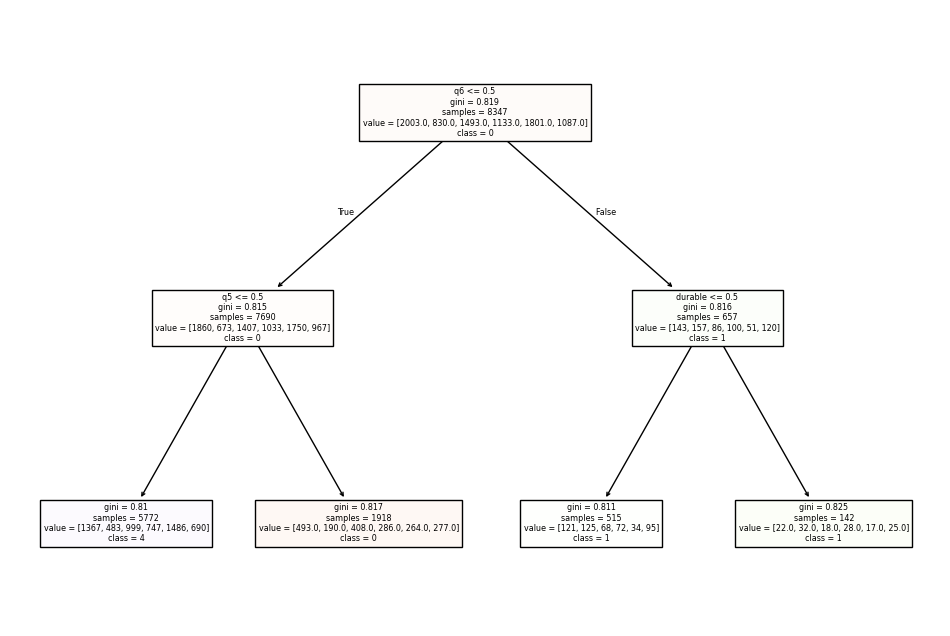

In [10]:
# Plot depth 2 tree
dtree = models["Decision Tree 2"]
dtree.fit(X_train, T_train)
plt.figure(figsize=(12, 8))
plot_tree(dtree, feature_names=X_train.columns, class_names=[str(c) for c in all_classes], filled=True)
plt.show()

In [11]:
# Going to use "Decision Tree 2" as final propensity model
final_propensity_model = models["Decision Tree 2"]
final_propensity_model.fit(X_train, T_train)
# Get predicted propensity scores for training and validation data
propensity_train = _predict_proba_all_classes(final_propensity_model, X_train, all_classes)
X_val = val.drop(columns=["inuidur1", "tg"])
propensity_val = _predict_proba_all_classes(final_propensity_model, X_val, all_classes)

print("\nPropensity scores (training data):")
print(pd.DataFrame(propensity_train, columns=[f"p(t={c})" for c in all_classes]).head())
print("\nPropensity scores (validation data):")
print(pd.DataFrame(propensity_val, columns=[f"p(t={c})" for c in all_classes]).head())



Propensity scores (training data):
     p(t=0)    p(t=1)    p(t=2)    p(t=3)    p(t=4)    p(t=5)
0  0.257039  0.099062  0.212722  0.149114  0.137643  0.144421
1  0.257039  0.099062  0.212722  0.149114  0.137643  0.144421
2  0.236833  0.083680  0.173077  0.129418  0.257450  0.119543
3  0.236833  0.083680  0.173077  0.129418  0.257450  0.119543
4  0.236833  0.083680  0.173077  0.129418  0.257450  0.119543

Propensity scores (validation data):
     p(t=0)    p(t=1)    p(t=2)    p(t=3)    p(t=4)    p(t=5)
0  0.234951  0.242718  0.132039  0.139806  0.066019  0.184466
1  0.236833  0.083680  0.173077  0.129418  0.257450  0.119543
2  0.234951  0.242718  0.132039  0.139806  0.066019  0.184466
3  0.236833  0.083680  0.173077  0.129418  0.257450  0.119543
4  0.236833  0.083680  0.173077  0.129418  0.257450  0.119543


In [12]:
# Estimate regression functions for each treatment group
# Helper functions for outcome regression model fitting and CV RMSE
def cv_rmse_outcome(model, X, Y, T, treatment_arms, cvsplit):

    rmses = []

    for fold, (tr_idx, te_idx) in enumerate(cvsplit.split(X), start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        Y_tr, Y_te = Y.iloc[tr_idx], Y.iloc[te_idx]
        T_tr, T_te = T.iloc[tr_idx], T.iloc[te_idx]

        sq_errors = []

        for k in treatment_arms:
            # indices for arm k
            tr_k = np.where(T_tr == k)[0]
            te_k = np.where(T_te == k)[0]

            if len(tr_k) == 0 or len(te_k) == 0:
                continue

            model_k = model()
            model_k.fit(X_tr.iloc[tr_k], Y_tr.iloc[tr_k])

            y_hat = model_k.predict(X_te.iloc[te_k])
            sq_errors.append((Y_te.iloc[te_k] - y_hat) ** 2)

        if sq_errors:
            fold_mse = np.mean(np.concatenate(sq_errors))
            rmses.append(np.sqrt(fold_mse))

    return np.mean(rmses), np.std(rmses), rmses

In [13]:
# Models to try for outcome regression
outcomemodels = {
    "Linear regression": lambda: LinearRegression(),
    "Tree 1": lambda: DecisionTreeRegressor(
        max_depth=2,
        min_samples_leaf=20,
        random_state=rng
    ),
    "Tree 2": lambda: DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=20,
        random_state=rng
    ),
    "Tree 3": lambda: DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=20,
        random_state=rng
    ),
    "Random forest 1": lambda: RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=20,
        random_state=rng,
        n_jobs=-1
    ),
    "Random forest 2": lambda: RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=60,
        random_state=rng,
        n_jobs=-1
    ),
    "Random forest 3": lambda: RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=120,
        random_state=rng,
        n_jobs=-1
    )
}

In [14]:
print("\n=== Outcome regression CV (TRAINING ONLY): RMSE ===")

outcome_results = {}

for name, model in outcomemodels.items():
    mean_rmse, sd_rmse, folds = cv_rmse_outcome(
        model, X_train, y_train, T_train, all_classes, cvsplit
    )
    outcome_results[name] = (mean_rmse, sd_rmse)
    print(f"{name:25s}  mean={mean_rmse:.4f}  sd={sd_rmse:.4f}  folds={[round(x,4) for x in folds]}")




=== Outcome regression CV (TRAINING ONLY): RMSE ===
Linear regression          mean=10.3813  sd=0.0891  folds=[np.float64(10.3168), np.float64(10.4433), np.float64(10.5217), np.float64(10.3476), np.float64(10.2774)]
Tree 1                     mean=10.4131  sd=0.0887  folds=[np.float64(10.3331), np.float64(10.505), np.float64(10.5264), np.float64(10.3944), np.float64(10.3067)]
Tree 2                     mean=10.4873  sd=0.0853  folds=[np.float64(10.3613), np.float64(10.522), np.float64(10.6158), np.float64(10.5012), np.float64(10.4361)]
Tree 3                     mean=10.5954  sd=0.0686  folds=[np.float64(10.4699), np.float64(10.6235), np.float64(10.6691), np.float64(10.5819), np.float64(10.6326)]
Random forest 1            mean=10.3847  sd=0.0625  folds=[np.float64(10.3246), np.float64(10.427), np.float64(10.4748), np.float64(10.3898), np.float64(10.3074)]
Random forest 2            mean=10.3713  sd=0.0739  folds=[np.float64(10.2926), np.float64(10.4429), np.float64(10.4683), np.float

In [15]:
# Given how similar things are. Just going to use linear models
# Look at estimated coefficients across control and the treatment arms
final_outcome_model = outcomemodels["Linear regression"]
coef_dfs = []
for k in all_classes:
    model_k = final_outcome_model()
    idx_k = np.where(T_train == k)[0]
    model_k.fit(X_train.iloc[idx_k], y_train.iloc[idx_k])
    coefs = pd.Series(model_k.coef_, index=X_train.columns, name=f"tg={k}")
    intercept = pd.Series({"Intercept": model_k.intercept_})
    coef_k = pd.concat([intercept, coefs])
    coef_dfs.append(coef_k)

coef_table = pd.concat(coef_dfs, axis=1)
print("\nEstimated coefficients for outcome regression models by treatment group:")
print(coef_table)



Estimated coefficients for outcome regression models by treatment group:
                    0          1          2          3          4          5
Intercept   12.930207  13.603969  11.832207  15.601237  14.583998  13.397450
female       0.672078  -0.163753   0.991249   1.653842   1.428232   1.603903
black       -2.088437  -3.190547  -3.059056  -1.944947  -1.570837  -2.663030
hispanic    -2.861834  -2.298571  -2.565456  -1.566185   0.286614  -2.736816
othrace     -5.420296  -5.053191   0.694779   2.693966  -0.964845   2.667036
q1           0.056348   0.234522  -3.182720  -0.046417   1.474370   2.760525
q2           0.520709  -1.517625   1.609155  -0.671047   0.013120   0.737778
q3           0.183620  -0.682765   1.219826  -1.134887  -0.793907  -1.870491
q4          -0.874548   0.580662  -0.723633  -0.314095  -0.815786  -0.914622
q5          -0.575623   0.655814   0.641730  -1.108012  -1.119510  -1.101485
q6           0.689494   0.729393   0.435641   3.274459   1.241713   0.388294
re

In [16]:
# Get predicted outcomes for training and validation data
outcome_preds_train = np.zeros((X_train.shape[0], len(all_classes)))
for i, k in enumerate(all_classes):
    model_k = final_outcome_model()
    idx_k = np.where(T_train == k)[0]
    model_k.fit(X_train.iloc[idx_k], y_train.iloc[idx_k])
    outcome_preds_train[:, i] = model_k.predict(X_train)
outcome_preds_val = np.zeros((X_val.shape[0], len(all_classes)))
for i, k in enumerate(all_classes):
    model_k = final_outcome_model()
    idx_k = np.where(T_train == k)[0]
    model_k.fit(X_train.iloc[idx_k], y_train.iloc[idx_k])
    outcome_preds_val[:, i] = model_k.predict(X_val)
# Show some of the predicted outcomes
print("\nPredicted outcomes (training data):")
print(pd.DataFrame(outcome_preds_train, columns=[f"mu(t={c})" for c in all_classes]).head())
print("\nPredicted outcomes (validation data):")
print(pd.DataFrame(outcome_preds_val, columns=[f"mu(t={c})" for c in all_classes]).head())



Predicted outcomes (training data):
     mu(t=0)    mu(t=1)    mu(t=2)    mu(t=3)    mu(t=4)    mu(t=5)
0  11.765459  11.970241  12.356786  12.675751  10.394426  12.405774
1  12.698096  13.593913  12.904471  13.970538  10.903930  12.604250
2  13.785905  12.757451  14.043283  16.120192  15.218323  13.130863
3  13.284238  10.800992  13.209523  12.768169  12.367809  14.765934
4  13.133681  13.220825  11.561066  16.224698  12.216313  14.340195

Predicted outcomes (validation data):
     mu(t=0)    mu(t=1)    mu(t=2)    mu(t=3)    mu(t=4)    mu(t=5)
0  12.687063  12.709689  11.720163  17.580908  15.316207  13.587268
1  12.689378  12.494714  13.328223  12.819754  11.527383  11.182593
2  12.687063  12.709689  11.720163  17.580908  15.316207  13.587268
3  18.426490  16.083154  17.266853  19.797367  15.989067  15.778254
4  10.992901  11.501180   9.800609  11.556391  11.505611  10.553039


# Policy Learning Section

In [17]:
# Some setup: actions, costs
actions = list(all_classes)
K = len(actions)
action_to_col = {a: j for j, a in enumerate(actions)}

# Allow different constant costs per arm; baseline 0 by default
default = True
if default:
    cost = {a: 0.0 for a in actions}
    cost_vec = np.array([cost[a] for a in actions], dtype=float)
else:  # Set costs to (0,.5,1,1,1.5,2)
    cost_values = [0.0, 0.5, 1.0, 1.0, 1.5, 2.0]
    cost = {a: c for a, c in zip(actions, cost_values)}
    cost_vec = np.array([cost[a] for a in actions], dtype=float)

In [18]:
def doubly_robust_scores(Y, T, p_hat, g_hat, actions, cost_vec):
    """
    Y: (n,) outcome
    T: (n,) observed action labels in 'actions'
    p_hat: (n,K) estimated propensities aligned to 'actions'
    g_hat: (n,K) estimated outcome regressions g_hat(k, X)
    cost_vec: (K,) constant cost per action
    returns: Gamma (n,K)
    """
    n = len(Y)

    # In this example, outcome is unemployment duration, so smaller is better
    # We will turn outcome into a "utility" type construct so that bigger
    # is better
    U = -Y
    u_hat = -g_hat

    Gamma = u_hat - cost_vec[None, :]

    # add the IPW residual term only to observed action column
    for j, a in enumerate(actions):
        idx = (T == a)
        if np.any(idx):
            # residual uses g_hat at the observed action (column j)
            Gamma[idx, :] += 0.0  # no-op; clarity
            Gamma[idx, j] += (U[idx] - u_hat[idx, j]) / p_hat[idx, j]

    return Gamma

def mean_and_se(x):
    """Return (mean, standard error) for a 1D array."""
    x = np.asarray(x, dtype=float)
    n = x.shape[0]
    mu = float(np.mean(x))
    se = float(np.std(x, ddof=1) / np.sqrt(n)) if n > 1 else np.nan
    return mu, se

def policy_value_from_Gamma(Gamma, pi, actions):
    """Deterministic policy value and SE using per-observation rewards in Gamma."""
    col = np.array([action_to_col[a] for a in pi], dtype=int)
    vals = Gamma[np.arange(Gamma.shape[0]), col]
    return mean_and_se(vals)


In [19]:
# Calculate "score" in training data and validation data
Gamma_train = doubly_robust_scores(
    Y=y_train.to_numpy(),
    T=T_train.to_numpy(),
    p_hat=propensity_train,
    g_hat=outcome_preds_train,
    actions=actions,
    cost_vec=cost_vec
)

y_val = val["inuidur1"]
T_val = val["tg"].astype(int)

Gamma_val = doubly_robust_scores(
    Y=y_val.to_numpy(),
    T=T_val.to_numpy(),
    p_hat=propensity_val,
    g_hat=outcome_preds_val,
    actions=actions,
    cost_vec=cost_vec
)



In [20]:
# Sanity check: Average outcome by treatment in training data
ave_outcomes = train.groupby("tg")["inuidur1"].mean()
print("\nAverage outcomes by treatment group (training data):")
print(ave_outcomes)

# Average DR score by treatment
avg_reward_by_action = Gamma_train.mean(axis=0)
best_constant_action = actions[int(np.argmax(avg_reward_by_action))]
print("\n=== Policy learning: baseline constant policy ===")
print("Avg DR reward by action:", {a: float(avg_reward_by_action[action_to_col[a]]) for a in actions})
print("Best constant action:", best_constant_action)
print("Avg DR reward in validation data by action:", {a: float(Gamma_val[:, action_to_col[a]].mean()) for a in actions})
val_means_ses = {a: mean_and_se(Gamma_val[:, action_to_col[a]]) for a in actions}
print("Avg DR reward in validation data by action (mean, se):", {a: (float(ms[0]), float(ms[1])) for a, ms in val_means_ses.items()})


Average outcomes by treatment group (training data):
tg
0    13.336495
1    13.273494
2    12.457468
3    13.156222
4    12.252082
5    12.801288
Name: inuidur1, dtype: float64

=== Policy learning: baseline constant policy ===
Avg DR reward by action: {np.int64(0): -13.287927781005202, np.int64(1): -13.061719511634395, np.int64(2): -12.508900144781398, np.int64(3): -13.22883247631932, np.int64(4): -12.309255709961013, np.int64(5): -12.786489442965246}
Best constant action: 4
Avg DR reward in validation data by action: {np.int64(0): -13.369778767651413, np.int64(1): -12.371696918155477, np.int64(2): -13.033901779819494, np.int64(3): -12.700950491480626, np.int64(4): -12.93852640043999, np.int64(5): -13.620403746848613}
Avg DR reward in validation data by action (mean, se): {np.int64(0): (-13.369778767651413, 0.2940466775898941), np.int64(1): (-12.371696918155477, 0.46476625048566866), np.int64(2): (-13.033901779819494, 0.32822874066128704), np.int64(3): (-12.700950491480626, 0.3937167

In [21]:
# Policy tree
class PolicyTreeNode:
    def __init__(self, depth=0):
        self.depth = depth
        self.is_leaf = True
        self.action = None
        self.feature = None
        self.left = None
        self.right = None
        self.reward = None  # best achievable total reward for this subtree

def _best_leaf_action(Gamma_sub, actions):
    sums = Gamma_sub.sum(axis=0)  # (K,)
    j = int(np.argmax(sums))
    return actions[j], float(sums[j])

def fit_policy_tree_exact_binary(X, Gamma, actions, max_depth=2, min_leaf=200, allow_reuse_features=False):
    """
    Exact search over binary splits for small max_depth.
    Objective: maximize sum over i of Gamma_{i, chosen_action_in_leaf}.
    At each leaf, choose best constant action (argmax over action sums).

    X: pd.DataFrame of binary features (0/1)
    Gamma: np.ndarray shape (n, K) aligned with 'actions'
    """
    X_np = X.to_numpy(dtype=int)
    n, p = X_np.shape

    # Precompute masks for each feature's 0/1 groups (over all data)
    feat0 = [X_np[:, j] == 0 for j in range(p)]
    feat1 = [~feat0[j] for j in range(p)]  # X==1

    # Cache on (mask_bytes, depth, used_features_bitmask) to speed things up
    from functools import lru_cache

    # represent "used features" as a bitmask (works up to ~60 features comfortably)
    # if you have more, set allow_reuse_features=True or switch to a frozenset.
    if p > 60 and not allow_reuse_features:
        raise ValueError("Too many features for bitmask without reuse. Set allow_reuse_features=True or reduce features.")

    def mask_to_bytes(mask):
        # pack bool mask into bytes for caching
        return np.packbits(mask.astype(np.uint8)).tobytes()

    @lru_cache(maxsize=None)
    def solve(mask_bytes, depth, used_mask):
        mask = np.unpackbits(np.frombuffer(mask_bytes, dtype=np.uint8))[:n].astype(bool)
        idx = np.where(mask)[0]

        node = PolicyTreeNode(depth=depth)

        # Leaf option (stop here)
        a_leaf, rew_leaf = _best_leaf_action(Gamma[idx, :], actions)
        node.action = a_leaf
        node.reward = rew_leaf
        node.is_leaf = True

        # If cannot split further, return leaf
        if depth >= max_depth or idx.size < 2 * min_leaf:
            return node

        best_node = node  # current best = leaf

        for j in range(p):
            if (not allow_reuse_features) and ((used_mask >> j) & 1):
                continue

            left_mask = mask & feat0[j]
            right_mask = mask & feat1[j]

            nl = int(left_mask.sum())
            nr = int(right_mask.sum())
            if nl < min_leaf or nr < min_leaf:
                continue

            new_used = used_mask if allow_reuse_features else (used_mask | (1 << j))

            left_node = solve(mask_to_bytes(left_mask), depth + 1, new_used)
            right_node = solve(mask_to_bytes(right_mask), depth + 1, new_used)

            total_rew = left_node.reward + right_node.reward

            if total_rew > best_node.reward + 1e-12:
                split_node = PolicyTreeNode(depth=depth)
                split_node.is_leaf = False
                split_node.feature = j
                split_node.left = left_node
                split_node.right = right_node
                split_node.reward = total_rew
                best_node = split_node

        return best_node

    full_mask = np.ones(n, dtype=bool)
    tree = solve(mask_to_bytes(full_mask), depth=0, used_mask=0)
    return tree

def predict_policy_tree(node, X, actions):
    X_np = X.to_numpy(dtype=int)
    n, _ = X_np.shape
    preds = np.empty(n, dtype=int)
    for i in range(n):
        cur = node
        while not cur.is_leaf:
            if X_np[i, cur.feature] == 0:
                cur = cur.left
            else:
                cur = cur.right
        preds[i] = cur.action
    return preds

def print_tree(node, feature_names, indent=""):
    if node.is_leaf:
        print(f"{indent}Leaf: action={node.action}, reward_sum≈{node.reward:.2f}")
        return
    fname = feature_names[node.feature]
    print(f"{indent}Split: {fname} (0 vs 1)  (subtree_reward_sum≈{node.reward:.2f})")
    print(f"{indent}  If {fname}=0:")
    print_tree(node.left, feature_names, indent + "    ")
    print(f"{indent}  If {fname}=1:")
    print_tree(node.right, feature_names, indent + "    ")



In [22]:
max_depth = 2
min_leaf = 30

X_train_pol = X_train.drop(columns=["q1", "q2", "q3", "q4", "q5", "q6"])
X_val_pol = X_val.drop(columns=["q1", "q2", "q3", "q4", "q5", "q6"])

tree = fit_policy_tree_exact_binary(
    X_train_pol, Gamma_train, actions,
    max_depth=max_depth,
    min_leaf=min_leaf,
    allow_reuse_features=False
)

print_tree(tree, feature_names=list(X_train_pol.columns))

Split: muld (0 vs 1)  (subtree_reward_sum≈-98560.55)
  If muld=0:
    Split: durable (0 vs 1)  (subtree_reward_sum≈-54745.01)
      If durable=0:
        Leaf: action=4, reward_sum≈-46171.55
      If durable=1:
        Leaf: action=1, reward_sum≈-8573.46
  If muld=1:
    Split: agelt35 (0 vs 1)  (subtree_reward_sum≈-43815.54)
      If agelt35=0:
        Leaf: action=5, reward_sum≈-21645.58
      If agelt35=1:
        Leaf: action=3, reward_sum≈-22169.96


In [23]:
# Evaluate tree value on TRAIN and VAL via mean Γ under the learned action
pi_train = predict_policy_tree(tree, X_train_pol, actions)
pi_val = predict_policy_tree(tree, X_val_pol, actions)

tr_value_mean, tr_value_se = policy_value_from_Gamma(Gamma_train, pi_train, actions)
print(f"\nPolicy tree value on TRAIN: {tr_value_mean:.6f} (se={tr_value_se:.6f})")
val_value, val_se = policy_value_from_Gamma(Gamma_val, pi_val, actions)
print(f"\nPolicy tree value on VAL: {val_value:.6f} (se={val_se:.6f})")


Policy tree value on TRAIN: -11.807901 (se=0.303791)

Policy tree value on VAL: -12.634693 (se=0.383035)


In [24]:
pi_val_table = pd.Series(pi_val, name="assigned_action").value_counts().to_frame()
print(pi_val_table)

                 count
assigned_action       
4                 2552
3                 1373
5                 1089
1                  552


In [25]:
# Smoothed policy optimization
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def fit_softmax_linear_policy(X, Gamma, tau=1.0, l2=1e-4, maxiter=500):
    """
    Returns theta of shape (d, K) for K actions, including intercept if you add one to X.
    """
    X_np = X.to_numpy()
    n, d = X_np.shape
    K = Gamma.shape[1]

    # Try scipy optimizer if available
    try:
        import scipy.optimize as opt

        def obj_and_grad(theta_flat):
            theta = theta_flat.reshape(d, K)
            Z = (X_np @ theta) / tau
            P = softmax(Z)                        # (n,K)
            # objective: mean_i sum_k P_ik * Gamma_ik  - (l2/2)*||theta||^2
            val = np.mean(np.sum(P * Gamma, axis=1)) - 0.5 * l2 * np.sum(theta**2)

            # gradient:
            # d/dtheta: (1/n) * X' * ( (P ⊙ (Gamma - E[Gamma|X])) / tau )  - l2*theta
            EG = np.sum(P * Gamma, axis=1, keepdims=True)     # (n,1)
            W = P * (Gamma - EG)                              # (n,K)
            grad = (X_np.T @ (W / tau)) / n - l2 * theta       # (d,K)

            return -val, -grad.ravel()

        theta0 = np.zeros((d, K), dtype=float).ravel()
        res = opt.minimize(
            fun=lambda th: obj_and_grad(th)[0],
            x0=theta0,
            jac=lambda th: obj_and_grad(th)[1],
            method="L-BFGS-B",
            options={"maxiter": maxiter}
        )
        theta_hat = res.x.reshape(d, K)
        return theta_hat, res

    except Exception as e:
        print("scipy optimize unavailable/failed; falling back to simple gradient ascent. Error:", e)

        theta = np.zeros((d, K), dtype=float)
        lr = 0.1
        for it in range(maxiter):
            Z = (X_np @ theta) / tau
            P = softmax(Z)
            EG = np.sum(P * Gamma, axis=1, keepdims=True)
            W = P * (Gamma - EG)
            grad = (X_np.T @ (W / tau)) / n - l2 * theta
            theta += lr * grad
            if (it+1) % 50 == 0:
                val = np.mean(np.sum(P * Gamma, axis=1)) - 0.5*l2*np.sum(theta**2)
                print(f"  iter {it+1:4d}: obj={val:.6f}")
        return theta, None

def add_intercept(X):
    X2 = X.copy()
    X2.insert(0, "Intercept", 1.0)
    return X2

def soft_policy_probs(X, theta, tau=1.0):
    X_np = X.to_numpy()
    Z = (X_np @ theta) / tau
    return softmax(Z)

def soft_policy_value(Gamma, P):
    """Stochastic policy value and SE using per-observation expected rewards."""
    per_obs = np.sum(P * Gamma, axis=1)
    return mean_and_se(per_obs)

In [26]:
# Include an intercept for the linear indices
Xtr_lin = add_intercept(X_train_pol)
Xva_lin = add_intercept(X_val_pol)

print("\n=== Fit smoothed softmax-linear policy on TRAIN ===")
theta_hat, optres = fit_softmax_linear_policy(Xtr_lin, Gamma_train, tau=1.0, l2=1e-4, maxiter=400)

P_tr = soft_policy_probs(Xtr_lin, theta_hat, tau=1.0)
P_va = soft_policy_probs(Xva_lin, theta_hat, tau=1.0)

# Deterministic version (argmax) if you want a "hard" policy from the soft one
pi_soft_val = np.array([actions[j] for j in np.argmax(P_va, axis=1)], dtype=int)

print("\nSmoothed-policy value estimates (mean DR reward):")
soft_tr, soft_tr_se = soft_policy_value(Gamma_train, P_tr)
soft_va, soft_va_se = soft_policy_value(Gamma_val,   P_va)
hard_va, hard_va_se = policy_value_from_Gamma(Gamma_val, pi_soft_val, actions)
print(f"  Soft policy (expected) on TRAIN: {soft_tr:.6f} (se={soft_tr_se:.6f})")
print(f"  Soft policy (expected) on VAL  : {soft_va:.6f} (se={soft_va_se:.6f})")
print(f"  Soft->hard argmax on VAL       : {hard_va:.6f} (se={hard_va_se:.6f})")




=== Fit smoothed softmax-linear policy on TRAIN ===

Smoothed-policy value estimates (mean DR reward):
  Soft policy (expected) on TRAIN: -11.044819 (se=0.264525)
  Soft policy (expected) on VAL  : -12.560006 (se=0.344827)
  Soft->hard argmax on VAL       : -12.576253 (se=0.351727)


In [27]:
policy_assignments = pd.Series(pi_soft_val, name="assigned_action")

policy_assignment_table = (
    policy_assignments
    .value_counts()
    .reindex(actions, fill_value=0)
    .rename("count")
    .to_frame()
)

policy_assignment_table["share"] = policy_assignment_table["count"] / policy_assignment_table["count"].sum()

print(policy_assignment_table)


                 count     share
assigned_action                 
0                    0  0.000000
1                   85  0.015271
2                  415  0.074560
3                  205  0.036831
4                 4405  0.791412
5                  456  0.081926


In [28]:
# Evaluate policy using only the validation observations that match the assigned
# policy. Reweight according to propensities.

def policy_value_ipw_hard(Y, T, p_hat, pi, actions, cost_vec,
                          clip=1e-12, normalize=False):
    """
    IPW evaluation for a deterministic (hard) policy pi(x) in a multi-action setting.

    Returns:
        value : float
        se    : float
    """
    Y = np.asarray(Y).astype(float)
    T = np.asarray(T).astype(int)
    pi = np.asarray(pi).astype(int)
    p_hat = np.asarray(p_hat).astype(float)

    n = len(Y)

    # Utility: smaller unemployment duration is better
    U = -Y

    # map each recommended action to column index
    pi_col = np.array([action_to_col[a] for a in pi], dtype=int)

    # matched observations: those where observed action equals policy action
    matched = (T == pi)

    # propensity for recommended action
    p_pi = np.clip(p_hat[np.arange(n), pi_col], clip, 1.0)

    # IPW weights
    w = np.zeros(n)
    w[matched] = 1.0 / p_pi[matched]

    # reward net of policy cost
    c_pi = cost_vec[pi_col]
    Z = w * (U - c_pi)

    if normalize:
        # Hájek (normalized) IPW
        denom = w.sum()
        if denom == 0:
            return np.nan, np.nan
        value = Z.sum() / denom

        # plug-in SE
        Z_tilde = Z / denom
        se = np.std(Z_tilde, ddof=1) * np.sqrt(n)
    else:
        # Standard IPW
        value = Z.mean()
        se = np.std(Z, ddof=1) / np.sqrt(n)

    return float(value), float(se)

def ipw_diagnostics_hard(T, pi):
    """Quick overlap diagnostics for hard policy evaluation."""
    T = np.asarray(T).astype(int)
    pi = np.asarray(pi).astype(int)
    matched = (T == pi)
    return {
        "match_rate": float(matched.mean()),
        "n_matched": int(matched.sum()),
        "n_total": int(len(T)),
    }

In [29]:
# IPW evaluation of tree policy on VAL
ipw_val, ipw_se = policy_value_ipw_hard(
    Y=y_val.to_numpy(),
    T=T_val.to_numpy(),
    p_hat=propensity_val,
    pi=pi_val,
    actions=actions,
    cost_vec=cost_vec,
    clip=1e-6,
    normalize=False
)

diag = ipw_diagnostics_hard(T_val.to_numpy(), pi_val)
print(f"Policy tree IPW value: {ipw_val:.6f} (se={ipw_se:.6f})")
print("IPW overlap diagnostics:", diag)

Policy tree IPW value: -13.337287 (se=0.581873)
IPW overlap diagnostics: {'match_rate': 0.17319439453826804, 'n_matched': 964, 'n_total': 5566}


In [30]:
# IPW evaluation of soft policy (made deterministic) on VAL
ipw_soft_argmax_val, ipw_soft_argmax_se = policy_value_ipw_hard(
    Y=y_val.to_numpy(),
    T=T_val.to_numpy(),
    p_hat=propensity_val,
    pi=pi_soft_val,
    actions=actions,
    cost_vec=cost_vec,
    clip=1e-6,
    normalize=False
)
print(f"Policy tree IPW value: {ipw_soft_argmax_val:.6f} (se={ipw_soft_argmax_se:.6f})")
print("Soft->hard overlap diagnostics:", ipw_diagnostics_hard(T_val.to_numpy(), pi_soft_val))

Policy tree IPW value: -12.649185 (se=0.531058)
Soft->hard overlap diagnostics: {'match_rate': 0.2019403521379806, 'n_matched': 1124, 'n_total': 5566}


In [31]:
def policy_value_ipw_constant(Y, T, p_hat, a, cost_vec, clip=1e-12, normalize=False):
    """
    IPW evaluation of the constant policy that always chooses action a.

    Returns:
        value : float
        se    : float

    Unnormalized IPW:
        value = (1/n) * sum_i 1{T_i=a} * (U_i - cost[a]) / p_hat(a|X_i)

    Normalized (Hájek) IPW:
        value = sum_i w_i * (U_i - cost[a]) / sum_i w_i
        with w_i = 1{T_i=a}/p_hat(a|X_i)
    """
    Y = np.asarray(Y).astype(float)
    T = np.asarray(T).astype(int)
    p_hat = np.asarray(p_hat).astype(float)

    n = len(T)
    U = -Y  # utility/reward convention

    a_col = action_to_col[a]
    p_a = np.clip(p_hat[:, a_col], clip, 1.0)

    matched = (T == a)

    # weights and per-observation contributions
    w = np.zeros(n)
    w[matched] = 1.0 / p_a[matched]

    reward = U - cost_vec[a_col]
    Z = w * reward  # contribution

    if normalize:
        denom = w.sum()
        if denom == 0:
            return np.nan, np.nan
        value = Z.sum() / denom

        # plug-in SE for normalized IPW (delta-method style via normalized contributions)
        Z_tilde = Z / denom
        se = np.std(Z_tilde, ddof=1) * np.sqrt(n)
    else:
        value = Z.mean()
        se = np.std(Z, ddof=1) / np.sqrt(n)

    return float(value), float(se)


def ipw_constant_policy_table(Y, T, p_hat, actions, cost_vec, clip=1e-6, normalize=False):
    """
    Produce a table of IPW values for policies that always choose a single action.
    Includes basic diagnostics (match rate, n matched, ESS) plus IPW standard error.
    """
    Y = np.asarray(Y).astype(float)
    T = np.asarray(T).astype(int)
    p_hat = np.asarray(p_hat).astype(float)

    rows = []
    n = len(T)

    for a in actions:
        a_col = action_to_col[a]
        matched = (T == a)

        p_a = np.clip(p_hat[:, a_col], clip, 1.0)
        w = np.zeros(n)
        w[matched] = 1.0 / p_a[matched]

        # Effective sample size (ESS) among matched obs
        w_m = w[matched]
        ess = (w_m.sum() ** 2) / (np.square(w_m).sum()) if w_m.size > 0 else 0.0

        val, se = policy_value_ipw_constant(
            Y, T, p_hat, a, cost_vec, clip=clip, normalize=normalize
        )

        rows.append({
            "action": a,
            "cost": float(cost_vec[a_col]),
            "ipw_value": float(val),
            "ipw_se": float(se),
            "match_rate": float(matched.mean()),
            "n_matched": int(matched.sum()),
            "ess_matched": float(ess),
            "mean_propensity": float(p_a.mean()),
            "min_propensity": float(p_a.min()),
        })

    df = pd.DataFrame(rows).sort_values("ipw_value", ascending=False).reset_index(drop=True)
    return df

In [32]:
single_action_ipw = ipw_constant_policy_table(
    Y=y_val.to_numpy(),
    T=T_val.to_numpy(),
    p_hat=propensity_val,
    actions=actions,
    cost_vec=cost_vec,
    clip=1e-6,
    normalize=False
)

print(single_action_ipw)


   action  cost  ipw_value    ipw_se  match_rate  n_matched  ess_matched  \
0       2   0.0 -12.235604  0.499986    0.167984        935   920.454684   
1       1   0.0 -12.609565  0.699861    0.099713        555   514.709100   
2       3   0.0 -12.618374  0.585734    0.135106        752   748.318544   
3       4   0.0 -13.476357  0.530289    0.220805       1229  1026.892701   
4       0   0.0 -13.511458  0.438345    0.242724       1351  1343.796211   
5       5   0.0 -14.088134  0.627783    0.133669        744   732.535983   

   mean_propensity  min_propensity  
0         0.179374        0.126761  
1         0.098922        0.083680  
2         0.135676        0.129418  
3         0.215487        0.066019  
4         0.240374        0.154930  
5         0.130167        0.119543  


In [33]:
# Put everything together: final policy evaluation table

pi_soft_train = np.array([actions[j] for j in np.argmax(P_tr, axis=1)], dtype=int)

rows = []

# --- Constant policies (each single treatment arm) ---
for a in actions:
    j = action_to_col[a]

    tr_mean, tr_se = mean_and_se(Gamma_train[:, j])
    va_mean, va_se = mean_and_se(Gamma_val[:, j])

    ipw_mean, ipw_se = policy_value_ipw_constant(
        Y=y_val.to_numpy(),
        T=T_val.to_numpy(),
        p_hat=propensity_val,
        a=a,
        cost_vec=cost_vec,
        clip=1e-6,
        normalize=False
    )

    rows.append({
        "policy": f"Action {a}",
        "train_DR": -tr_mean,
        "train_DR_se": tr_se,
        "val_DR": -va_mean,
        "val_DR_se": va_se,
        "val_IPW": -ipw_mean,
        "val_IPW_se": ipw_se,
    })

# --- Tree policy ---
tree_tr_mean, tree_tr_se = policy_value_from_Gamma(Gamma_train, pi_train, actions)
tree_va_mean, tree_va_se = policy_value_from_Gamma(Gamma_val,   pi_val,   actions)
tree_ipw_mean, tree_ipw_se = policy_value_ipw_hard(
    Y=y_val.to_numpy(),
    T=T_val.to_numpy(),
    p_hat=propensity_val,
    pi=pi_val,
    actions=actions,
    cost_vec=cost_vec,
    clip=1e-6,
    normalize=False
)

rows.append({
    "policy": "Tree policy",
    "train_DR": -tree_tr_mean,
    "train_DR_se": tree_tr_se,
    "val_DR": -tree_va_mean,
    "val_DR_se": tree_va_se,
    "val_IPW": -tree_ipw_mean,
    "val_IPW_se": tree_ipw_se,
})

# --- Hard version of the smoothed policy (argmax) ---
soft_hard_tr_mean, soft_hard_tr_se = policy_value_from_Gamma(Gamma_train, pi_soft_train, actions)
soft_hard_va_mean, soft_hard_va_se = policy_value_from_Gamma(Gamma_val,   pi_soft_val,   actions)
soft_hard_ipw_mean, soft_hard_ipw_se = policy_value_ipw_hard(
    Y=y_val.to_numpy(),
    T=T_val.to_numpy(),
    p_hat=propensity_val,
    pi=pi_soft_val,
    actions=actions,
    cost_vec=cost_vec,
    clip=1e-6,
    normalize=False
)

rows.append({
    "policy": "Soft policy (hard argmax)",
    "train_DR": -soft_hard_tr_mean,
    "train_DR_se": soft_hard_tr_se,
    "val_DR": -soft_hard_va_mean,
    "val_DR_se": soft_hard_va_se,
    "val_IPW": -soft_hard_ipw_mean,
    "val_IPW_se": soft_hard_ipw_se,
})

results_table = pd.DataFrame(rows)

print("\n=== Final policy value summary table ===")
print(results_table.to_string(index=False, float_format=lambda x: f"{x: .6f}"))


=== Final policy value summary table ===
                   policy   train_DR  train_DR_se     val_DR  val_DR_se    val_IPW  val_IPW_se
                 Action 0  13.287928     0.230718  13.369779   0.294047  13.511458    0.438345
                 Action 1  13.061720     0.368899  12.371697   0.464766  12.609565    0.699861
                 Action 2  12.508900     0.264418  13.033902   0.328229  12.235604    0.499986
                 Action 3  13.228832     0.313516  12.700950   0.393717  12.618374    0.585734
                 Action 4  12.309256     0.262063  12.938526   0.350264  13.476357    0.530289
                 Action 5  12.786489     0.322117  13.620404   0.399288  14.088134    0.627783
              Tree policy  11.807901     0.303791  12.634693   0.383035  13.337287    0.581873
Soft policy (hard argmax)  10.936634     0.270396  12.576253   0.351727  12.649185    0.531058
